# **Original CNN Binary Model**

## Libraries

In [ ]:
# Libraries
import sys
import os
import re
import random
import shutil
import math

import pandas as pd
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize, ImageDataGenerator

from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dense, Activation, GlobalAveragePooling2D, Input, BatchNormalization, Dropout, Lambda, GlobalMaxPooling2D, Concatenate
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from tensorflow.keras import regularizers
from scikeras.wrappers import KerasClassifier

from focal_loss import BinaryFocalLoss

import optuna

from deep.constants import DATA_DIR, IMAGE_DIR, IMG_SIZE, BATCH_SIZE, SEED
from deep.preprocessing.label_oversampler import compute_effective_class_weights

2025-04-21 20:21:54.557412: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-21 20:21:54.568300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-21 20:21:54.580313: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-21 20:21:54.584410: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-21 20:21:54.592812: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(f'{DATA_DIR}/metadata.csv')

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [5]:
# Performing the splits
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['is_animal'], random_state=20)  # Create test set
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['is_animal'], random_state=20)  # Create validation set

In [8]:
# Changing target to string
train_df['is_animal'] = train_df['is_animal'].astype(str)
val_df['is_animal'] = val_df['is_animal'].astype(str)
test_df['is_animal'] = test_df['is_animal'].astype(str)

In [11]:
def smart_resize_img(image, target_size=(IMG_SIZE, IMG_SIZE)):
    resized_img = smart_resize(image, target_size)  # Resize image
    resized_img /= 255.0  # Normalize the image
    
    return resized_img

In [16]:
def show_augmented_images(generator, num_images=8):
    images, labels = next(generator)

    actual_num = min(num_images, len(images))  # Avoid index errors

    max_cols = 4
    rows = math.ceil(actual_num / max_cols)
    plt.figure(figsize=(max_cols * 3, rows * 3))

    for i in range(actual_num):
        plt.subplot(rows, max_cols, i + 1)
        plt.imshow(images[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=90,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    channel_shift_range=30.0,
    zoom_range=(0.8, 1.2),
    fill_mode='nearest',
    preprocessing_function=smart_resize_img
)
test_datagen = ImageDataGenerator(preprocessing_function=smart_resize_img)

# Train generator
binary_train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=True  # shuffle for training
)

# Validation generator
binary_val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Test generator
binary_test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 9533 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


2025-04-21 20:21:57.157989: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-04-21 20:21:57.158041: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: shadybea
2025-04-21 20:21:57.158051: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: shadybea
2025-04-21 20:21:57.158378: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 550.120.0
2025-04-21 20:21:57.158440: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: 550.120.0
2025-04-21 20:21:57.158448: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:249] kernel version seems to match DSO: 550.120.0


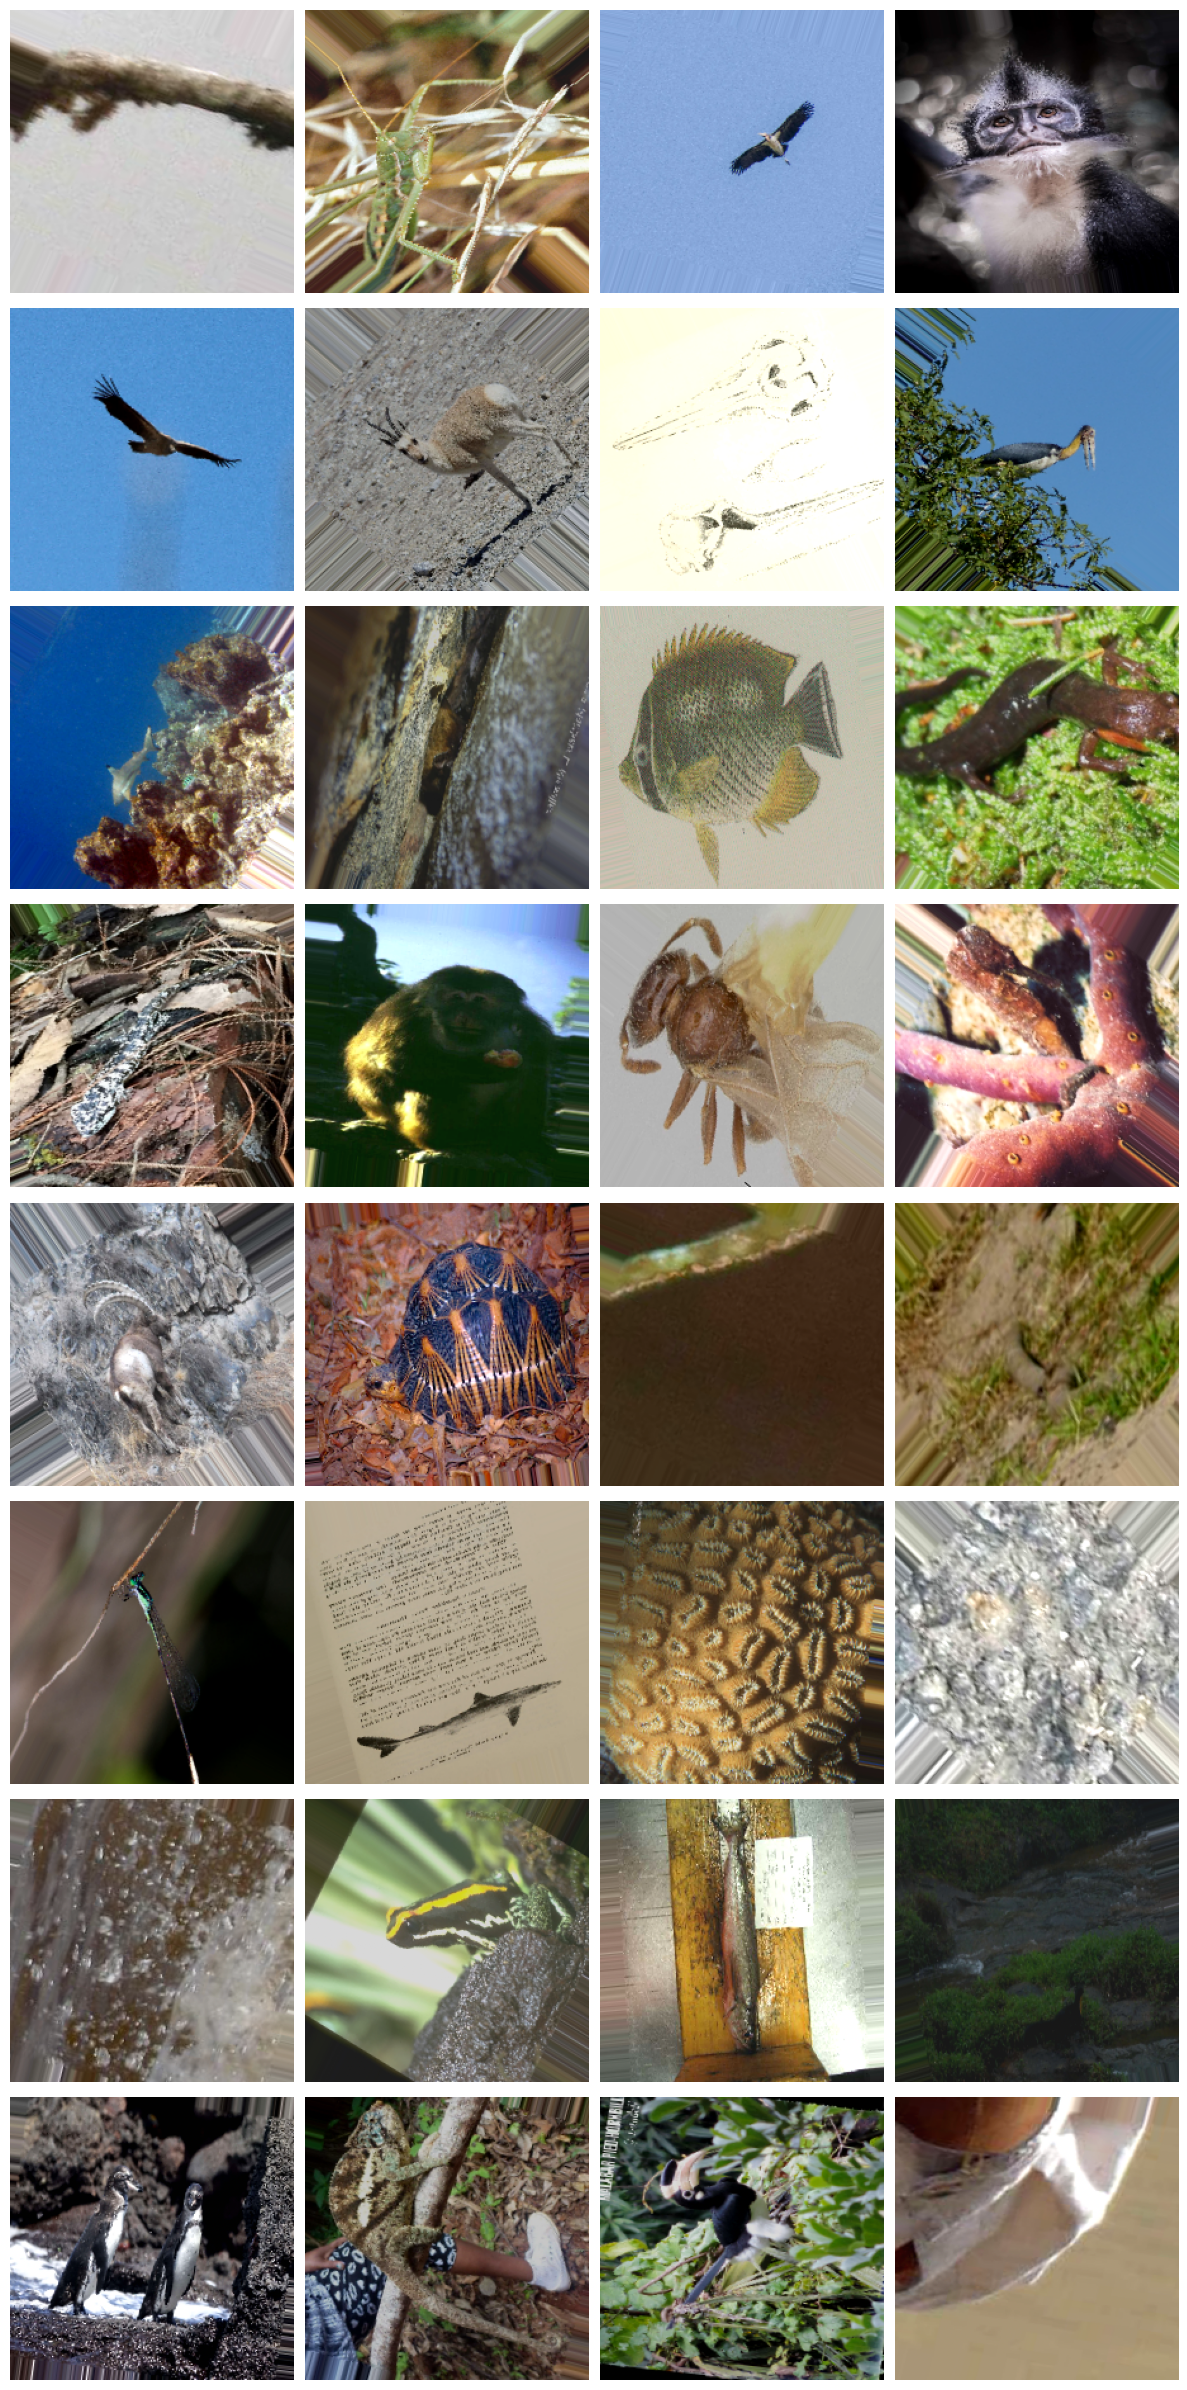

In [ ]:
# Show augmented images - rerun for new batch
show_augmented_images(binary_train_generator, num_images=8)

## Modelling

In [ ]:
# Compute class weights
class_weights = compute_effective_class_weights(train_df, 'is_animal')

In [ ]:
# Define the CNN model
binary_model = Sequential()

# Input Layer + 1st Convolutional Block
binary_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
binary_model.add(MaxPooling2D((2, 2)))

# 2nd Convolutional Block
binary_model.add(Conv2D(64, (3, 3), activation='relu'))
binary_model.add(MaxPooling2D((2, 2)))

# 3rd Convolutional Block
binary_model.add(Conv2D(128, (3, 3), activation='relu'))
binary_model.add(MaxPooling2D((2, 2)))

# 4th Convolutional Block
binary_model.add(Conv2D(128, (3, 3), activation='relu'))
binary_model.add(MaxPooling2D((2, 2)))

# Fully Connected Layer
binary_model.add(Flatten())
binary_model.add(Dropout(0.5))
binary_model.add(Dense(512, activation='relu'))

# Output Layer for Binary Classification
binary_model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Compiling the model
binary_model.compile(
    optimizer=RMSprop(learning_rate=0.0001)
    ,loss='binary_crossentropy'
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [ ]:
# Show model summary
binary_model.summary()

In [47]:
# Fit the model
fitted_binary = binary_model.fit(
    binary_train_generator
    ,validation_data=binary_val_generator
    ,epochs=5
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True)
        ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

Epoch 1/5
148/298 ━━━━━━━━━━━━━━━━━━━━ 4:16 2s/step - accuracy: 0.5061 - auc_3: 0.4971 - loss: 0.1939 - precision: 0.8032 - recall: 0.5154

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


298/298 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.5119 - auc_3: 0.4978 - loss: 0.1856 - precision: 0.7990 - recall: 0.5228 - val_accuracy: 0.0709 - val_auc_3: 0.5634 - val_loss: 0.1097 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step - accuracy: 0.5704 - auc_3: 0.5229 - loss: 0.1376 - precision: 0.8087 - recall: 0.6094 - val_accuracy: 0.9291 - val_auc_3: 0.6228 - val_loss: 0.0775 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.5696 - auc_3: 0.5084 - loss: 0.1066 - precision: 0.7896 - recall: 0.6170 - val_accuracy: 0.9249 - val_auc_3: 0.4880 - val_loss: 0.0626 - val_precision: 0.9331 - val_recall: 0.9903 - learning_rate: 1.0000e-04
Epoch 4/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.5890 - auc_3: 0.4892 - loss: 0.0813 - precision: 0.7965 - recall: 0.6528 - val_accuracy: 0.0709 - val_auc_3: 0.501

In [ ]:
history = fitted_binary.history

# Get best epoch metrics
best_epoch = np.argmin(history['val_loss'])

# Loss
best_train_loss = history['loss'][best_epoch]
best_val_loss = history['val_loss'][best_epoch]
print(f"Train Loss: {best_train_loss}\nValidation Loss: {best_val_loss}")
# Accuracy
best_train_acc = history['accuracy'][best_epoch]
best_val_acc = history['val_accuracy'][best_epoch]
print(f"Train Accuracy:{best_train_acc}\nValidation Accuracy: {best_val_acc}")

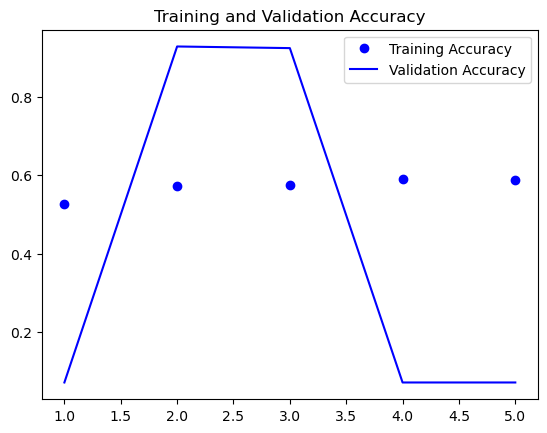

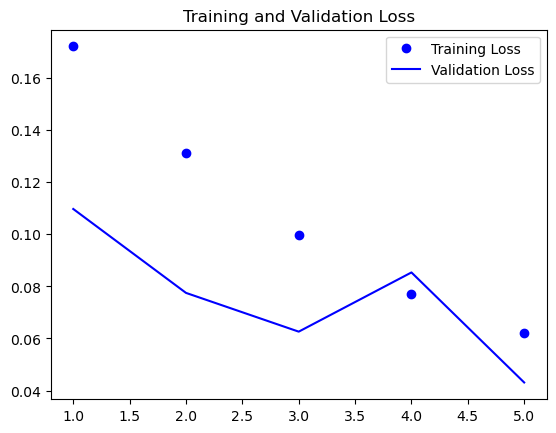

In [49]:
# Defining the variables
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']
epochs = range(1, len(acc) + 1)

# Accuracy plot
plt.plot(
    epochs
    ,acc
    ,'bo'
    ,label='Training Accuracy'
)
plt.plot(
    epochs
    ,val_acc
    ,'b'
    ,label='Validation Accuracy'
)
plt.title("Training and Validation Accuracy")
plt.legend()

plt.figure()

# Loss plot
plt.plot(
    epochs
    ,loss
    ,'bo'
    ,label='Training Loss'
)
plt.plot(
    epochs
    ,val_loss
    ,'b'
    ,label='Validation Loss'
)
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [52]:
# Make predictions
predictions = binary_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

75/75 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step


In [53]:
# Get the true labels
y_true = binary_test_generator.labels

# Convert predictions to class labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")

Accuracy: 0.0705
Precision: 0.0000
Recall: 0.0000


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
# Get unique values and their counts
unique, counts = np.unique(y_pred, return_counts=True)

# Display the result
value_counts = dict(zip(unique, counts))
print(value_counts)

{0: 2397}


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Animal', 'Animal'],
            yticklabels=['Not Animal', 'Animal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [55]:
# # Save the predictions
# file_paths = binary_test_generator.filenames
# pred_df = pd.DataFrame({
#     'file_path': file_paths,
#     'predictions': (predictions > 0.5).astype(int).flatten()
# })

# # Export to csv
# # pred_df.to_csv('../models/binary_predictions.csv', index=False)